In [ ]:

import pandas as pd
import numpy as np
import yfinance as yf

from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.trend import EMAIndicator
from ta.volatility import BollingerBands

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from sklearn.preprocessing import MinMaxScaler

import shap
from sqlalchemy import create_engine

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#tenserflow implementation

# Scale the features using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)

X_seq = []
y_seq = []

sequence_length = 10
#window_data
for i in range(
    sequence_length,
    len(X_scaled)
):
    X_seq.append(
        X_scaled[
            i-sequence_length:i
        ]
    )
    y_seq.append(y.iloc[i])
X_seq = np.array(X_seq)

y_seq = np.array(y_seq)


In [ ]:
X_seq = np.array(X_seq)
y_seq = np.array(y_seq) + 1 # Shift labels to 0, 1, 2, 3 for classification

# Reshape X_seq for LSTM input: (samples, timesteps, features)
X_seq = np.reshape(X_seq, (X_seq.shape[0], X_seq.shape[1], X_seq.shape[2]))

In [ ]:
split = int(0.8 * len(X_seq))

X_train = X_seq[:split]

X_test = X_seq[split:]

y_train = y_seq[:split]

y_test = y_seq[split:]

In [ ]:
model = Sequential()
model.add(

    LSTM(

        64,

        return_sequences=False,

        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#dropout
model.add(
    Dropout(0.2)
)
# Output layer for multi-class classification (4 classes: 0, 1, 2, 3)
model.add(Dense(len(np.unique(y_seq)), activation='softmax'))
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy", # Use sparse for integer-encoded labels
    metrics=["accuracy"]
)
model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(
        X_test,
        y_test
    )
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3514 - loss: 1.2909 - val_accuracy: 0.3215 - val_loss: 1.3793
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3640 - loss: 1.2824 - val_accuracy: 0.3259 - val_loss: 1.3813
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3671 - loss: 1.2775 - val_accuracy: 0.3454 - val_loss: 1.3985
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3742 - loss: 1.2743 - val_accuracy: 0.3850 - val_loss: 1.3160
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3697 - loss: 1.2736 - val_accuracy: 0.3906 - val_loss: 1.3240
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3685 - loss: 1.2702 - val_accuracy: 0.3942 - val_loss: 1.3344
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3745 - loss: 1.2696 - val_accuracy: 0.3630 - val_loss: 1.3591
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3733 - loss: 1.2692 - val_accuracy

In [ ]:
#stocks we want to predict
stocks = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "TSLA"
]
all_data = []

for stock in stocks:

    df = yf.download(
        stock,
        start="2015-01-01",
        end="2025-01-01"
    )

    df.columns = df.columns.get_level_values(0)

    df["Stock"] = stock

    all_data.append(df)

data = pd.concat(all_data)

/tmp/ipykernel_11651/2547609665.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_11651/2547609665.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_11651/2547609665.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_11651/2547609665.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_11651/2547609665.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%*************

In [ ]:
#company fundamentals
fundamental_data = []

for stock in stocks:

    company = yf.Ticker(stock)

    info = company.info

    temp = {
        "Stock": stock,
        "MarketCap": info.get("marketCap", np.nan),
        "PE": info.get("trailingPE", np.nan),
        "RevenueGrowth": info.get("revenueGrowth", np.nan),
        "ProfitMargins": info.get("profitMargins", np.nan),
        "Beta": info.get("beta", np.nan)
    }

    fundamental_data.append(temp)

fund_df = pd.DataFrame(fundamental_data)
data = data.merge(
    fund_df,
    on="Stock",
    how="left"
)

In [ ]:
data["RSI"] = RSIIndicator(
    close=data["Close"]
).rsi()
data["MACD"] = MACD(
    close=data["Close"]
).macd()
data["EMA"] = EMAIndicator(
    close=data["Close"]
).ema_indicator()
bb = BollingerBands(close=data["Close"])

data["BB_High"] = bb.bollinger_hband()

data["BB_Low"] = bb.bollinger_lband()
data["Daily_Return"] = data["Close"].pct_change()

data["Volatility"] = (
    data["High"] - data["Low"]
) / data["Close"]

data["Volume_Change"] = (
    data["Volume"].pct_change()
)

In [ ]:
#risk intellegence
data["Daily_Return"] = data["Close"].pct_change()

data["Volatility"] = (
    data["High"] - data["Low"]
) / data["Close"]

data["Volume_Change"] = (
    data["Volume"].pct_change()
)

In [ ]:
from ta.momentum import ROCIndicator
from ta.trend import SMAIndicator, ADXIndicator

# Momentum
data["momentum"] = ROCIndicator(close=data["Close"], window=12).roc()

# MA_Ratio (example: 20-day SMA / 50-day SMA)
data["SMA_20"] = SMAIndicator(close=data["Close"], window=20).sma_indicator()
data["SMA_50"] = SMAIndicator(close=data["Close"], window=50).sma_indicator()
data["MA_Ratio"] = data["SMA_20"] / data["SMA_50"]

# Trend Strength (ADX)
adx = ADXIndicator(high=data["High"], low=data["Low"], close=data["Close"], window=14)
data["trend_strength"] = adx.adx()

In [ ]:
# Drop the intermediate SMA columns if not needed
data = data.drop(columns=["SMA_20", "SMA_50"], errors='ignore')

In [ ]:
#target prediction
data["Future_Return"] = (

    (
        data["Close"].shift(-5)

        -

        data["Close"]

    )

    /

    data["Close"]

)

In [ ]:
#targets
conditions = [

    data["Future_Return"] > 0.05,

    data["Future_Return"] > 0.01,

    data["Future_Return"] > -0.01,

    data["Future_Return"] <= -0.01
]

values = [2, 1, 0, -1]

data["Target"] = np.select(
    conditions,
    values
)

# Drop rows with NaN values after all feature and target calculations
data.dropna(inplace=True)

In [ ]:
data["Stock_Code"] = (
    data["Stock"]
    .astype("category")
    .cat.codes
)

In [ ]:
features = [
    "RSI",
    "MACD",
    "EMA",
    "BB_High",
    "BB_Low",
    "Volume",
    "Daily_Return",
    "Volatility",
    "Volume_Change",
    "MarketCap",
    "momentum",
    "MA_Ratio",
    "trend_strength",
    "PE",
    "RevenueGrowth",
    "ProfitMargins",
    "Beta",
    "Stock_Code"
]

X = data[features]

y = data["Target"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

# Adjust y_train and y_test to be non-negative for XGBoost
model.fit(X_train, y_train + 1)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pred = model.predict(X_test)

acc = accuracy_score(y_test, pred)

print("Train Score:",
      model.score(X_train, y_train))

print("Test Score:", acc)

Train Score: 0.06117764471057884
Test Score: 0.15003990422984836


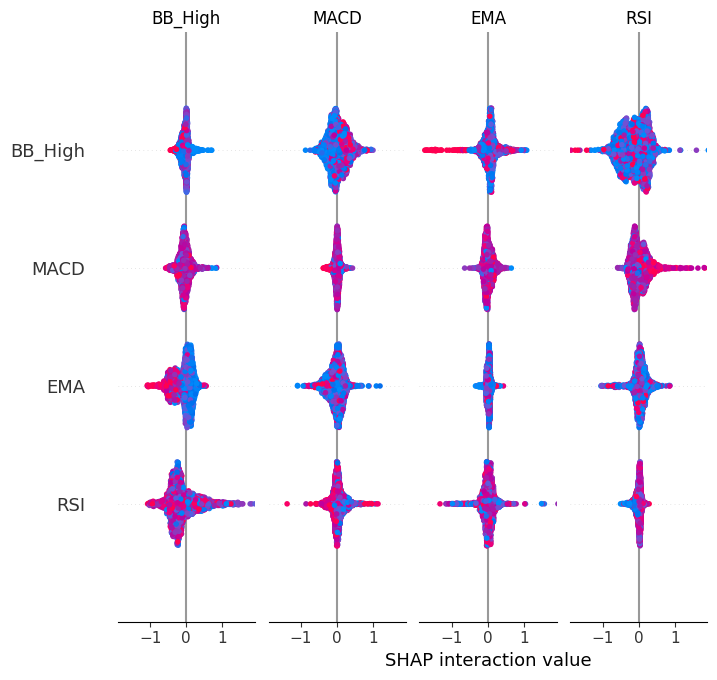

In [ ]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)
shap.summary_plot(
    shap_values,
    X_test
)

In [ ]:
latest_data = X.tail(1)

latest_pred = model.predict(latest_data)[0]

latest_prob = model.predict_proba(latest_data)[0]

confidence = max(latest_prob) * 100

if confidence < 60:
    signal = "HOLD"

elif latest_pred == 1:
    signal = "BUY"

else:
    signal = "SELL"

print("AI Recommendation:", signal)

print("Confidence:",
      round(confidence, 2), "%")
# print("risk_level",risk) # Commented out due to NameError

AI Recommendation: SELL
Confidence: 93.37 %


In [ ]:
pip install xgboost


In [ ]:
!pip install tensorflow